### Import libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

 ### Load the diabetes dataset

In [17]:
df = pd.read_csv("diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Check dataset shape

In [18]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


### Check column names

In [20]:
print(df.columns.tolist())

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


### Check data types

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Summary statistics

In [24]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### Check missing values

In [26]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Check duplicate rows

In [28]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


### Histograms

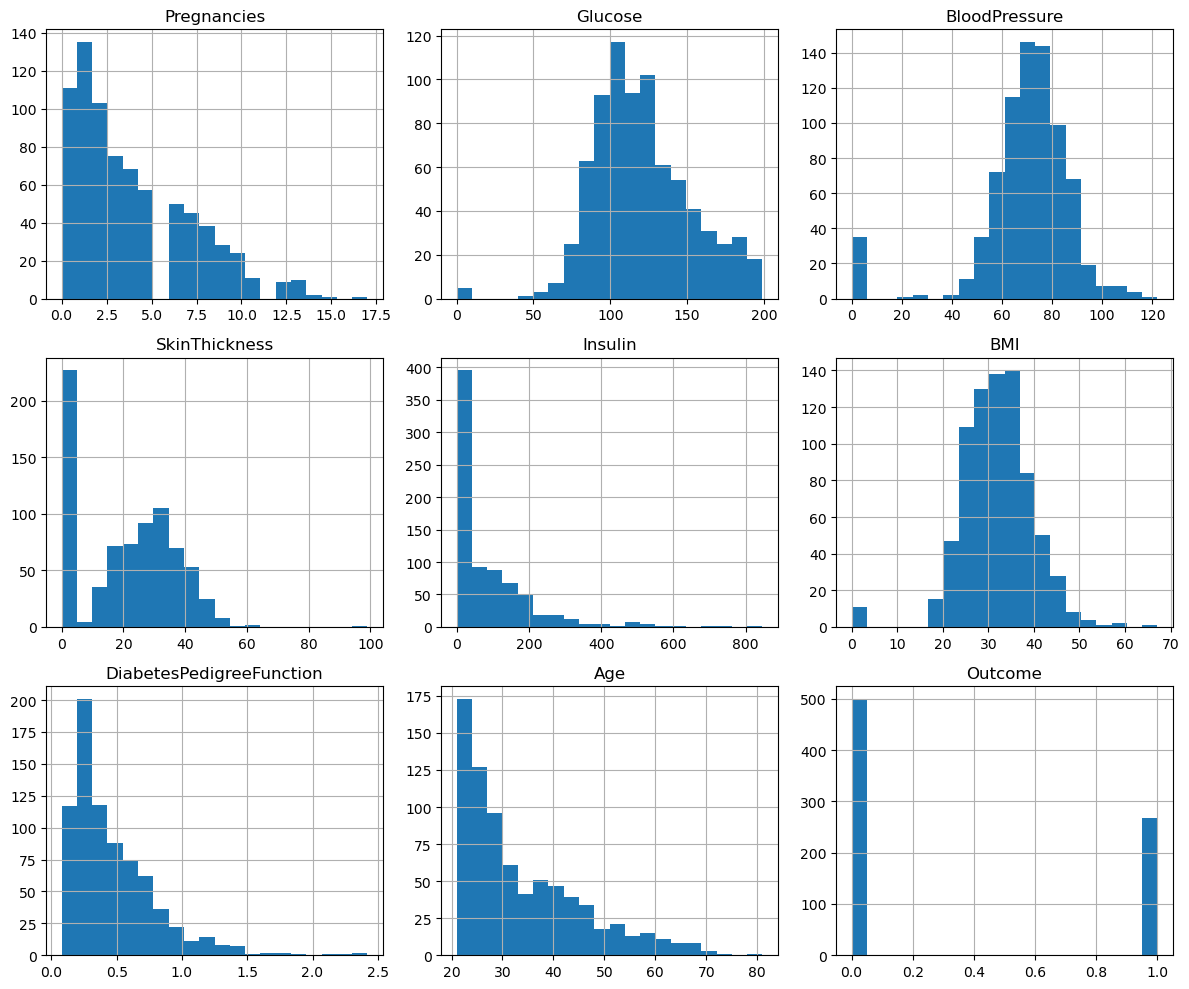

In [30]:
df.hist(figsize=(12, 10), bins=20)

plt.tight_layout()
plt.show()

### Box plots

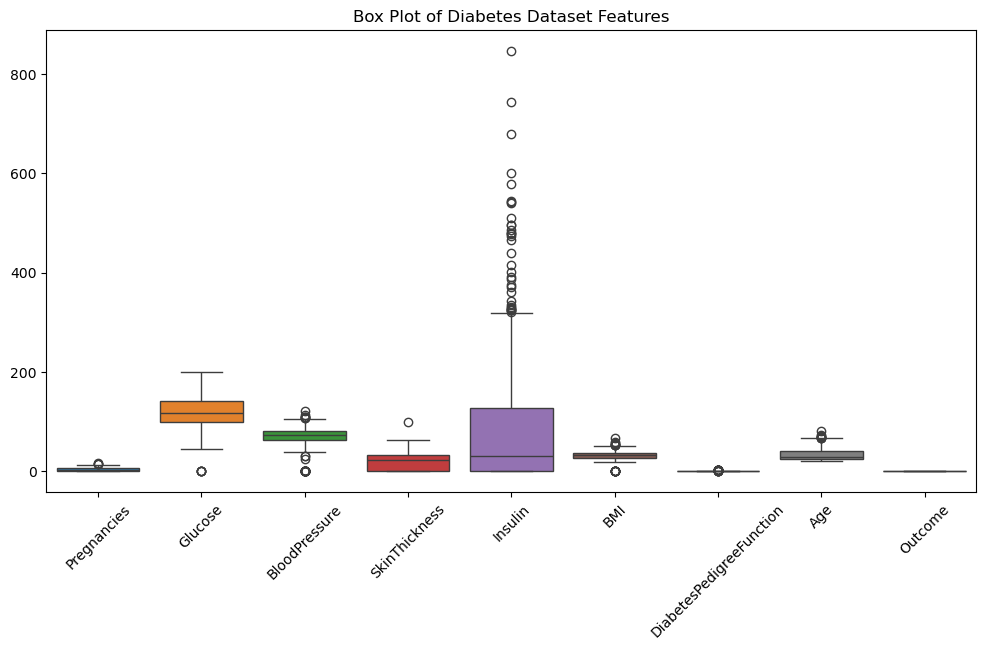

In [32]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df)

plt.xticks(rotation=45)
plt.title("Box Plot of Diabetes Dataset Features")
plt.show()

### Correlation heatmap

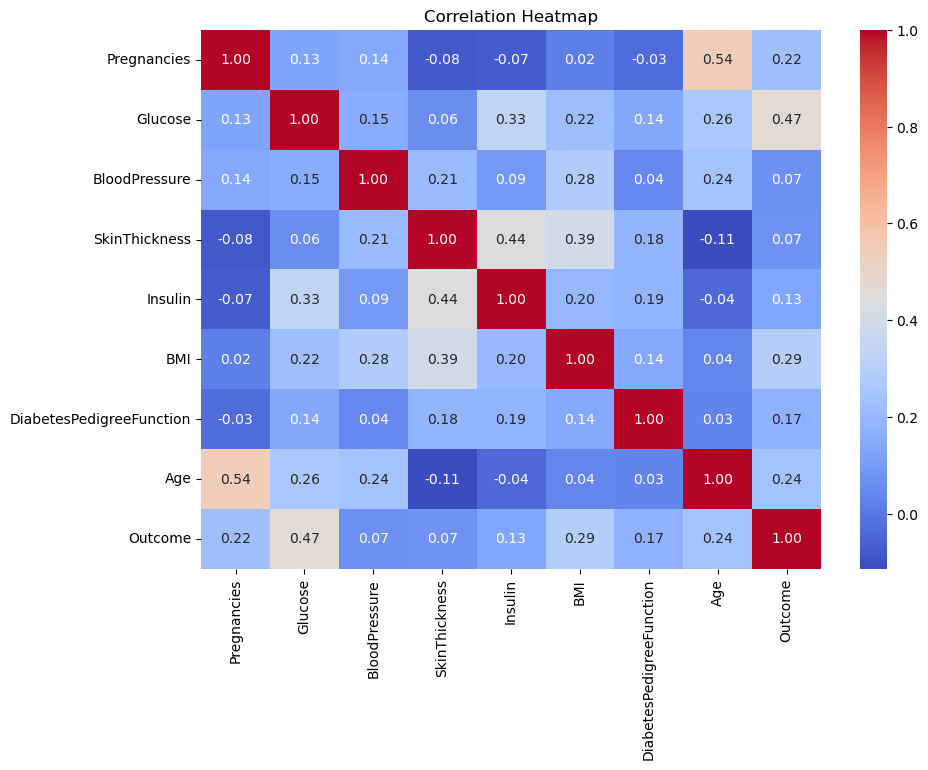

In [34]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

### Outcome distribution

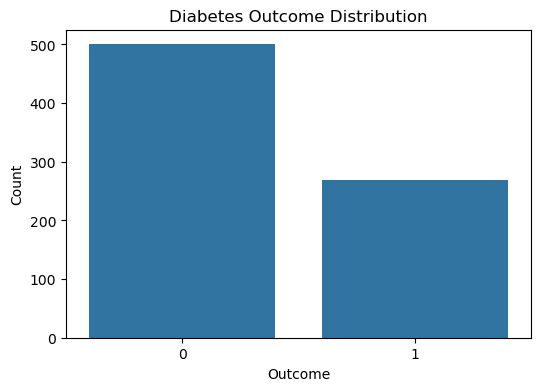

In [36]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Outcome", data=df)

plt.title("Diabetes Outcome Distribution")
plt.xlabel("Outcome")
plt.ylabel("Count")

plt.show()

### Separate features and target

In [38]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

Target:
Outcome


### Split into training and testing data

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


### Feature scaling

In [42]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


### Create model

In [45]:
logistic_model = LogisticRegression(random_state=42)

### Train model

In [46]:
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


### Make predictions

In [48]:
y_pred = logistic_model.predict(X_test_scaled)

y_probability = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed.")

Predictions completed.


### Calculate metrics

In [50]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_probability)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.7142857142857143
Precision: 0.6086956521739131
Recall   : 0.5185185185185185
F1 Score : 0.56
ROC-AUC  : 0.8229629629629629


### Classification report

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.82      0.79       100
           1       0.61      0.52      0.56        54

    accuracy                           0.71       154
   macro avg       0.68      0.67      0.67       154
weighted avg       0.71      0.71      0.71       154



### Confusion matrix

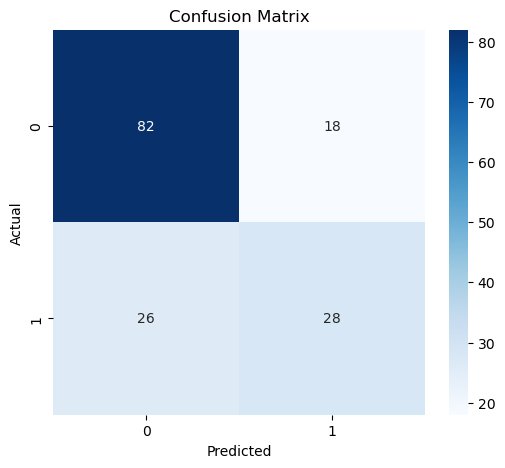

In [54]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### ROC curve

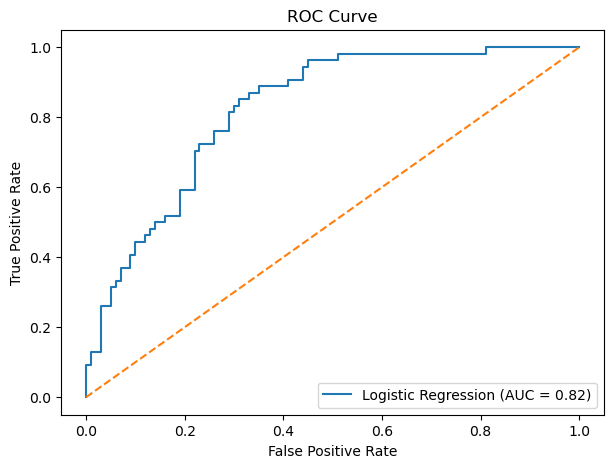

In [56]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.2f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

### Display coefficients

In [58]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients

,Feature,Coefficient
0,Pregnancies,0.373178
1,Glucose,1.144151
2,BloodPressure,-0.197637
3,SkinThickness,0.066535
4,Insulin,-0.127308
5,BMI,0.713893
6,DiabetesPedigreeFunction,0.255527
7,Age,0.184179


### Sort coefficients

In [60]:
coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
1,Glucose,1.144151
5,BMI,0.713893
0,Pregnancies,0.373178
6,DiabetesPedigreeFunction,0.255527
7,Age,0.184179
3,SkinThickness,0.066535
4,Insulin,-0.127308
2,BloodPressure,-0.197637


### Save Logistic Regression model

In [63]:
joblib.dump(
    logistic_model,
    "logistic_regression_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


### Save scaler

In [66]:
joblib.dump(
    scaler,
    "scaler.pkl"
)

print("Scaler saved successfully.")

Scaler saved successfully.


### Test That the Saved Model Works

In [69]:
loaded_model = joblib.load(
    "logistic_regression_model.pkl"
)

loaded_scaler = joblib.load(
    "scaler.pkl"
)

print("Model and scaler loaded successfully.")

Model and scaler loaded successfully.


### Test one prediction

In [72]:
sample = pd.DataFrame([{
    "Pregnancies": 6,
    "Glucose": 148,
    "BloodPressure": 72,
    "SkinThickness": 35,
    "Insulin": 0,
    "BMI": 33.6,
    "DiabetesPedigreeFunction": 0.627,
    "Age": 50
}])

# Scale the sample
sample_scaled = loaded_scaler.transform(sample)

# Prediction
prediction = loaded_model.predict(sample_scaled)[0]

# Probability
probability = loaded_model.predict_proba(sample_scaled)[0][1]

print("Prediction:", prediction)
print("Diabetes Probability:", probability)

Prediction: 1
Diabetes Probability: 0.7313999375935318


In [73]:
### Create app.py

In [76]:
app_code = '''
import streamlit as st
import pandas as pd
import joblib

# Load trained model and scaler
model = joblib.load("logistic_regression_model.pkl")
scaler = joblib.load("scaler.pkl")

# Page title
st.set_page_config(
    page_title="Diabetes Prediction"
)

st.title("Diabetes Prediction using Logistic Regression")

st.write(
    "Enter the patient's information below to predict "
    "the probability of diabetes."
)

# User inputs
pregnancies = st.number_input(
    "Pregnancies",
    min_value=0,
    max_value=20,
    value=1
)

glucose = st.number_input(
    "Glucose",
    min_value=0.0,
    max_value=250.0,
    value=120.0
)

blood_pressure = st.number_input(
    "Blood Pressure",
    min_value=0.0,
    max_value=200.0,
    value=70.0
)

skin_thickness = st.number_input(
    "Skin Thickness",
    min_value=0.0,
    max_value=100.0,
    value=20.0
)

insulin = st.number_input(
    "Insulin",
    min_value=0.0,
    max_value=900.0,
    value=80.0
)

bmi = st.number_input(
    "BMI",
    min_value=0.0,
    max_value=70.0,
    value=30.0
)

diabetes_pedigree = st.number_input(
    "Diabetes Pedigree Function",
    min_value=0.0,
    max_value=3.0,
    value=0.5
)

age = st.number_input(
    "Age",
    min_value=1,
    max_value=120,
    value=30
)

# Prediction button
if st.button("Predict Diabetes"):

    input_data = pd.DataFrame([{
        "Pregnancies": pregnancies,
        "Glucose": glucose,
        "BloodPressure": blood_pressure,
        "SkinThickness": skin_thickness,
        "Insulin": insulin,
        "BMI": bmi,
        "DiabetesPedigreeFunction": diabetes_pedigree,
        "Age": age
    }])

    # Scale input
    input_scaled = scaler.transform(input_data)

    # Make prediction
    prediction = model.predict(input_scaled)[0]

    probability = model.predict_proba(input_scaled)[0][1]

    st.subheader("Prediction Result")

    if prediction == 1:
        st.error("The model predicts: Diabetes")
    else:
        st.success("The model predicts: No Diabetes")

    st.write(
        f"Probability of diabetes: {probability:.2%}"
    )

    st.info(
        "This prediction is generated by a machine learning model "
        "and should not be considered a medical diagnosis."
    )
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("app.py created successfully.")

app.py created successfully.


### the end